In [39]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [40]:
X, y = make_classification(n_samples=100, n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [41]:
df = pd.DataFrame(X, columns=["Col1", "Col2", "Col3", "Col4", "Col5"])
df["target"] = y
df.head()

,Col1,Col2,Col3,Col4,Col5,target
0,-0.188603,-0.099170,0.802929,-0.758220,-2.636955,0
1,0.149840,0.999556,-1.486625,-1.143019,-3.621520,1
2,-0.282659,0.011098,0.859365,0.151316,2.363214,1
3,-4.317016,-0.111750,4.347246,0.936086,1.254132,0
4,0.124811,-1.961051,-0.677991,-1.816190,-1.065303,0


In [42]:
df.shape

(100, 6)

In [43]:
# Function for row sampling
def sample_rows(df, percent):
  return df.sample(int(percent*df.shape[0]), replace=True)

In [44]:
# Function for column sampling
def sample_column(df, percent):
  cols = random.sample(df.columns.tolist()[:-1], int(percent*df.shape[1]))
  return df[cols]

In [45]:
#  Function for combined sampling
def sample_combined(df, row_percent, col_percent):
  new_df = sample_rows(df, row_percent)
  return sample_column(new_df, col_percent)

In [46]:
df1 = sample_rows(df, 0.2)

In [47]:
df2 = sample_rows(df, 0.2)

In [48]:
df3 = sample_rows(df, 0.2)

In [49]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [50]:
clf1.fit(df1.iloc[:, 0:5], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:5], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:5], df3.iloc[:, -1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [51]:
from sklearn.tree import plot_tree

[Text(0.4, 0.875, 'x[0] <= -2.147\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[4] <= -1.16\ngini = 0.305\nsamples = 16\nvalue = [3, 13]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[2] <= -1.177\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]')]

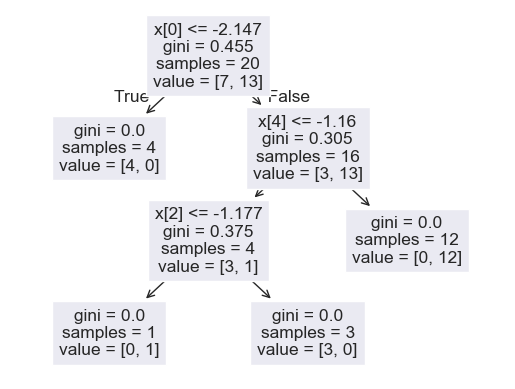

In [52]:
plot_tree(clf1)

[Text(0.5, 0.75, 'x[2] <= 0.124\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.625, 0.5, '  False')]

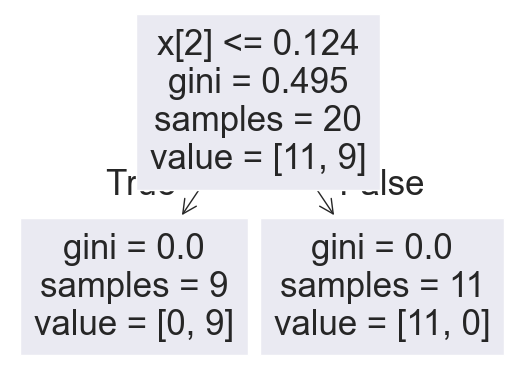

In [53]:
plot_tree(clf2)

[Text(0.5, 0.8333333333333334, 'x[2] <= -0.34\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.25, 0.5, 'x[3] <= 0.831\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.75, 0.5, 'x[4] <= 1.809\ngini = 0.165\nsamples = 11\nvalue = [10, 1]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

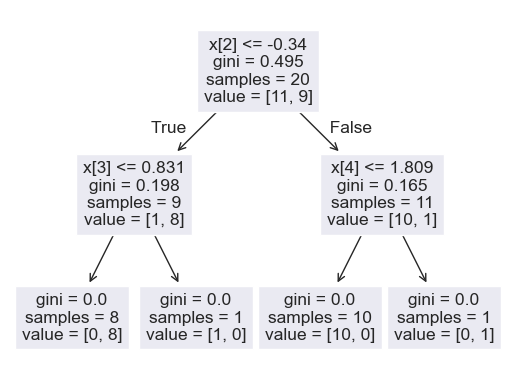

In [54]:
plot_tree(clf3)

In [55]:
# Prediction
clf1.predict(np.array([0.551380, -1.876815, -1.807618, -1.557932, -0.039809]).reshape(1, 5))

D:\Complete ML\Data Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [56]:
clf2.predict(np.array([0.551380, -1.876815, -1.807618, -1.557932, -0.039809]).reshape(1, 5))

D:\Complete ML\Data Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [57]:
clf3.predict(np.array([0.551380, -1.876815, -1.807618, -1.557932, -0.039809]).reshape(1, 5))

D:\Complete ML\Data Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])